# Putative Genetic Load
Given that the tara iti reference genome could not be annotated with RNA sequencing, ensure a robust and conservative assessment of genetic load that is translatable across species comparisons, we limited load estimates to highly conserved BUSCO genes in the fairy tern species complex (*Sterna nereis* spp.) and kakī (*Himantopus novazealandiae*) for comparison.  

To start, we ran BUSCO v5.4.7 for the tara iti and kakī reference genome.  

We then concatenated single copy BUSCO sequences into species specific `GFF` files.  

First we fixed the concatenated `GFF` from BUSCO to be more compatible with Ensemble's Variant Effect Predictor (VEP) with  [agat](https://github.com/NBISweden/AGAT) v. 1.0.0.    

Regions where the end position is before the start position were corrected before sorting, file compression with `bgzip` and indexing with `tabix`.  130 records in the TI genome and 55 records in the kaki genome had ending positions that occurred before the start positions. These start/end positions were flipped in order to not crash VEP.  

In [ ]:
cat KI_annotations/merged_scBUSCO_checked.gff | \
    awk '{ if ($5>$4) print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > KI_annotations/merged_autosomal_checkedV2_noBadSites.gff.gz
cat TI_annotations/merged_scBUSCO_checked.gff | \
    awk '{ if ($5>$4) print $0}' | \
    sort -k1,1 -k4,4n -k5,5n -t$'\t' | bgzip -c > TI_annotations/merged_autosomal_checkedV2_noBadSites.gff.gz

tabix -p gff KI_annotations/scBUSCO_coorinates_fixed.gff.gz
tabix -p gff TI_annotations/scBUSCO_coorinates_fixed.gff.gz

The sum of sc-BUSCO gene regions is 289,743,567bp in kakī and 227,780,539bp in tara iti. This corresponds to roughly 26% and 21% of the kakī and fairy tern genomes. 

### Sites Polarised with ANGSD
To estimate masked and realised load in each fairy tern population and kakī we used ANGSD to output the major minor alleles, the called genotype, the posterior probability of the called genotype and all possible genotypes (`-doGeno 31`) to a BCF file (`-doBcf 1`).  

In [ ]:
angsd -P 24 -b ${ANGSD}GLOBAL.list -ref ${TREF} -anc ${TANC} -out ${ANGSD}samtools/genotypes/GLOBAL_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 56 -setMinDepth 545 -setMaxDepth 1038 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0

angsd -P 32 -b ${DIR}KI.list -ref ${KREF} -anc ${KANC} -out ${DIR}samtools/genotypes/KI_polarized \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 -skipTriallelic 1 \
        -minMapQ 20 -minQ 20 -minInd 24 -setMinDepth 700 -maxDepth 1200 -doCounts 1 \
        -doPost 1 -postCutoff 0.95 -doBcf 1 -GL 1 -doMajorMinor 5 -doMaf 1 -SNP_pval 1e-6 -doGeno 31 --ignore-RG 0

### Variant Effect Predictor
Ensemble's [Variant Effect Predictor](https://www.ensembl.org/info/docs/tools/vep/vep_formats.html#output) (VEP) is a tool for analyzing tool for inferring the coding consequences of sequence variation. VEP was run below using the GTF files constructed above.  

In [ ]:
vep -i ${CHR}_snp.vcf \
    --custom file=TI_annotations/merged_autosomal_scBUSCOs_checkedV2_noBadSites.gff.gz,short_name=TI_BUSCOs,format=gff,type=overlap \
    --fasta Katie_autosomes.fa \
    -o ${CHR}_SNP_vep.vcf \
    --vcf --buffer_size 1

vep --vcf -i ${CHR}_sv.vcf \
    --custom file=TI_annotations/merged_autosomal_scBUSCOs_checkedV2_noBadSites.gff.gz,short_name=TI_BUSCOs,format=gff,type=overlap \
    --fasta Katie_autosomes.fa \
    -o ${CHR}_SV_vep.vcf \
    --vcf --buffer_size 1

VEP identifies the type of mutation and assigns a level of 'severity' to the mutation. This ranges from high, moderate, low, and modifier. A summary of each is in the table below. 

| Consequence |     Definition     |
|:-----------:|:------------------:|
|     Low     | Assumed to be mostly harmless or unlikely to change protein behaviour.  | 
|   Moderate  | A non-disruptive variant that might change protein effectiveness. |
|     High    | The variant is assumed to have high impact on the protein, probably causing truncation, loss of function, or triggering nonsense mediated decay. |
|   Modifier  | Usually non-coding variants or variants affecting non-codeing genes, where predictions are difficult or there is no evidence of impact. |

Given that the 'Modifier' consequence is assigned to mutations where predictions are difficult or there is a lack of evidence, the only mutations assigned as modifiers that were retained were intergenic variants. These are used later in our estimates of R<sub>*XY*</sub>.  

Below we count the number of alleles of each consequence for tara iti, Australian fairy tern. This loop was modified and run for kakī in the same manner.  

In [ ]:
# SNP genotypes
bcftools query -S AU.list -f '[%CHROM\t%POS\t%SAMPLE\t%GT\t%CSQ\n]' GLOBAL_SNP_vep.vcf \
    | sed 's/|/\t/g' | awk -f '{print $1"\t"$2"\t"$3"\t"$4"\t"$6"\t"$7"\tAU"}' > indiv_snp_vep_allele_freq.tsv
bcftools query -S TI.list -f '[%CHROM\t%POS\t%SAMPLE\t%GT\t%CSQ\n]' GLOBAL_SNP_vep.vcf \
    | sed 's/|/\t/g' | awk -f '{print $1"\t"$2"\t"$3"\t"$4"\t"$6"\t"$7"\tNZ"}' >> indiv_snp_vep_allele_freq.tsv
bcftools query -f '[%CHROM\t%POS\t%SAMPLE\t%GT\t%CSQ\n]' KI_variable_alt.vcf \
    | sed 's/|/\t/g' | awk -f '{print $1"\t"$2"\t"$3"\t"$4"\t"$6"\t"$7"\tKI"}' >> indiv_snp_vep_allele_freq.tsv

# SV genotypes - This was run on the VCF output from VEP to ensure the correct SV was correlated with the correct consequence
bcftools query -S AU.list -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SVLEN\t%SAMPLE\t%GT\t%CSQ\n]' Fairy_sv_vep.vcf \
    | sed 's/|/\t/g' | awk '{print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t"$7"\t"$9"\t"$10"\tAU"}' > indiv_sv_vep_allele_freq.tsv
bcftools query -S TI.list -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SVLEN\t%SAMPLE\t%GT\t%CSQ\n]' Fairy_sv_vep.vcf \
    | sed 's/|/\t/g' | awk '{print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t"$7"\t"$9"\t"$10"\tNZ"}' >> indiv_sv_vep_allele_freq.tsv
bcftools query -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SVLEN\t%SAMPLE\t%GT\t%CSQ\n]' KI_svs_VEP.vcf \
    | sed 's/|/\t/g' | awk '{print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t"$7"\t"$9"\t"$10"\tKI"}' >> indiv_sv_vep_allele_freq.tsv

## Load Estimates
We first imported our python libraries for subsequent analyses.  


In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress
from sklearn.metrics import r2_score
from scipy.stats import mannwhitneyu
from scipy import stats

#path = '/nesi/nobackup/uc03718/'
#os.chdir(path)
print(os.getcwd())

c:\Users\jwold\GitHub\2026_S_nereis_Cons_Gen


However, there were a few SNP sites in the fairy tern and kakī data sets that had ambiguous impacts. That is to say the same site had multiple mutation types and consequences. After loading the data from our files, these sites were excluded from all downstream analyses to ensure a conservative estimate of putative mutation load.  

In [2]:
snp_vep = pd.read_csv('indiv_snp_vep_allele_freq.tsv', 
                      sep='\t', 
                      names=['Chromosome', 'Position', 'Sample', 'Genotype', 
                             'Mutation Class', 'Consequence', 'Population'])
sv_vep = pd.read_csv('indiv_sv_vep_allele_freq.tsv', 
                     sep='\t', 
                     names=['Chromosome', 'Start', 'End', 'Sample', 'Genotype', 'SV Type', 
                            'Mutation Class', 'Consequence', 'Population'])

In [3]:
# Now changing genotypes to allele counts
replace_map = {
    '0/0': 0,
    '0/1': 1,
    '1/1': 2
}

snp_vep['Allele Count'] = snp_vep['Genotype'].replace(replace_map)
snp_vep = snp_vep.drop(columns=['Genotype'])

sv_vep['Allele Count'] = sv_vep['Genotype'].replace(replace_map)
sv_vep = sv_vep.drop(columns=['Genotype'])

snp_conditions = [
    snp_vep['Allele Count'] == 0,
    snp_vep['Allele Count'] == 1,
    snp_vep['Allele Count'] == 2
]

sv_conditions = [
    sv_vep['Allele Count'] == 0,
    sv_vep['Allele Count'] == 1,
    sv_vep['Allele Count'] == 2
]

categories = ['Hom Ref', 'Het', 'Hom Alt']

snp_vep['Genotype Category'] = np.select(snp_conditions, categories, default='Unknown')
sv_vep['Genotype Category'] = np.select(sv_conditions, categories, default='Unknown')

C:\Users\jwold\AppData\Local\Temp\ipykernel_24916\2048133484.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snp_vep['Allele Count'] = snp_vep['Genotype'].replace(replace_map)
C:\Users\jwold\AppData\Local\Temp\ipykernel_24916\2048133484.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sv_vep['Allele Count'] = sv_vep['Genotype'].replace(replace_map)


In [4]:
sv_vep['SV Length'] = sv_vep['End'] - sv_vep['Start']

sv_vep[sv_vep['Mutation Class']!='MODIFIER'].head()

,Chromosome,Start,End,Sample,SV Type,Mutation Class,Consequence,Population,Allele Count,Genotype Category,SV Length
0,CM020437.1_RagTag,2867602,2874189,SND04,deletion,intergenic_variant,MODIFIER,NZ,0,Hom Ref,6587
1,CM020437.1_RagTag,2867602,2874189,SND06,deletion,intergenic_variant,MODIFIER,NZ,0,Hom Ref,6587
2,CM020437.1_RagTag,2867602,2874189,SND11,deletion,intergenic_variant,MODIFIER,NZ,0,Hom Ref,6587
3,CM020437.1_RagTag,2867602,2874189,SP02,deletion,intergenic_variant,MODIFIER,NZ,0,Hom Ref,6587
4,CM020437.1_RagTag,2867602,2874189,SP03,deletion,intergenic_variant,MODIFIER,NZ,0,Hom Ref,6587


Double checking that ambiguous sites have been excluded. 

In [5]:
snpdupes = snp_vep[snp_vep.duplicated(subset=['Chromosome', 'Position',
                                              'Population', 'Sample'], keep=False)]
svdupes = sv_vep[sv_vep.duplicated(subset=['Chromosome', 'Start',
                                           'SV Type', 'Population', 'Sample'], keep=False)]

print("Number of duplicated SNP records: ", len(snpdupes), "Total number of SNP records: ", len(snp_vep))
print("Number of duplicated SV records: ", len(svdupes), "Total number of SV records: ", len(sv_vep))

Number of duplicated SNP records:  0 Total number of SNP records:  78212088
Number of duplicated SV records:  112 Total number of SV records:  323872


We have 0 SNP dupes, so are good to progress to aggregating the individual counts into population counts. However, we found a few duplicates in the SVs. This is due to a potentially unresolved Duplication SV in the fairy tern population as observed below. 

In [6]:
svdupes.to_csv('duplicated_SV_sites.tsv', sep='\t', index=True)
svdupes.drop_duplicates(subset=['Chromosome', 'Start', 'End', 'SV Type', 'SV Length'])

,Chromosome,Start,End,Sample,SV Type,Mutation Class,Consequence,Population,Allele Count,Genotype Category,SV Length
170829,CM020452.1_RagTag,5295673,5295972,SND04,duplication,downstream_gene_variant,MODIFIER,NZ,0,Hom Ref,299
170866,CM020452.1_RagTag,5295673,5296087,SND04,duplication,downstream_gene_variant,MODIFIER,NZ,1,Het,414


In this casse, SV type, mutation class, and consequence of this SV is the same. However, the genotype did not agree between the two records. We excluded this SV from down stream analyses so as to not inflate our estimates of impactful SVs. This record was also excluded from estimates of heterozygosity, and population structure.  

In [7]:
sv_vep = sv_vep[
    ~(
        (sv_vep['Chromosome']=='CM020452.1_RagTag') &
        (sv_vep['Start']==5295673) &
        (sv_vep['End'].isin([5295972, 5296087])) &
        (sv_vep['SV Type']=='DUP')
    )
]

In [8]:
pop_snps = snp_vep.groupby(['Chromosome', 'Position', 'Population'], as_index=False).agg({
    'Allele Count': 'sum',
    'Mutation Class': 'first',
    'Consequence': 'first'
})

pop_svs = sv_vep.groupby(['Chromosome', 'Start', 'End', 'SV Type', 'SV Length', 'Population'], as_index=False).agg({
    'Allele Count': 'sum',
    'Mutation Class': 'first',
    'Consequence': 'first'
})

# And now estimating allele frequency 
snp_conditions = [
    pop_snps['Population']=='AU',
    pop_snps['Population']=='NZ',
    pop_snps['Population']=='KI'
]

sv_conditions = [
    pop_svs['Population']=='AU',
    pop_svs['Population']=='NZ',
    pop_svs['Population']=='KI'
]

denominators = [2*19, 2*37, 2*24] # Double the population size for each

pop_snps['Allele Frequency'] = pop_snps['Allele Count'] / np.select(snp_conditions, denominators, default=np.nan)
pop_svs['Allele Frequency'] = pop_svs['Allele Count'] / np.select(sv_conditions, denominators, default=np.nan)
pop_snps.head()

,Chromosome,Position,Population,Allele Count,Mutation Class,Consequence,Allele Frequency
0,CM020437.1_RagTag,322008,AU,1,intergenic_variant,MODIFIER,0.026316
1,CM020437.1_RagTag,322008,NZ,1,intergenic_variant,MODIFIER,0.013514
2,CM020437.1_RagTag,2527725,AU,17,intergenic_variant,MODIFIER,0.447368
3,CM020437.1_RagTag,2527725,NZ,0,intergenic_variant,MODIFIER,0.000000
4,CM020437.1_RagTag,2527963,AU,17,intergenic_variant,MODIFIER,0.447368


### SNP SFS by mutation class and consequence
We used the SFS to explore the distribution of synonymous derived alleles in each population.  

The highly binary share of the SFS for tara iti is going to be potentially problematic for later R<sub>XY</sub> estimates given the fact that the vast majority of these alleles are either absent or fixed, making the denominator == 0.  Will explore in more detail in the R<sub>XY</sub> section below.  

We also wanted to explore the shape of the SFS for missense muations and compare with the Low, Moderate, and High impact alleles as indicated by VEP.  

In [10]:
synonymous_count = pop_snps[pop_snps['Mutation Class']=='synonymous_variant']

au_counts = synonymous_count[synonymous_count['Population']=='AU'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
au_lowCounts = pop_snps[(pop_snps['Population']=='AU') & (pop_snps['Consequence']=='LOW') & (pop_snps['Mutation Class']!='synonymous_variant')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
au_modCounts = pop_snps[(pop_snps['Population']=='AU') & (pop_snps['Consequence']=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
au_highCounts = pop_snps[(pop_snps['Population']=='AU') & (pop_snps['Consequence']=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

nz_counts = synonymous_count[synonymous_count['Population']=='NZ'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
nz_lowCounts = pop_snps[(pop_snps['Population']=='NZ') & (pop_snps['Consequence']=='LOW') & (pop_snps['Mutation Class']!='synonymous_variant')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
nz_modCounts = pop_snps[(pop_snps['Population']=='NZ') & (pop_snps['Consequence']=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
nz_highCounts = pop_snps[(pop_snps['Population']=='NZ') & (pop_snps['Consequence']=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

ki_counts = synonymous_count[synonymous_count['Population']=='KI'].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ki_lowCounts = pop_snps[(pop_snps['Population']=='KI') & (pop_snps['Consequence']=='LOW') & (pop_snps['Mutation Class']!='synonymous_variant')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ki_modCounts = pop_snps[(pop_snps['Population']=='KI') & (pop_snps['Consequence']=='MODERATE')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")
ki_highCounts = pop_snps[(pop_snps['Population']=='KI') & (pop_snps['Consequence']=='HIGH')].groupby(["Allele Count", "Population"]).size().reset_index(name="Frequency")

#pivot data for barplots
au_pivot = au_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,39), fill_value=0)
au_Lowpivot = au_lowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,39), fill_value=0)
au_Modpivot = au_modCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,39), fill_value=0)
au_Highpivot = au_highCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,39), fill_value=0)

nz_pivot = nz_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,75), fill_value=0)
nz_Lowpivot = nz_lowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 75), fill_value=0)
nz_Modpivot = nz_modCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 75), fill_value=0)
nz_Highpivot = nz_highCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 75), fill_value=0)

ki_pivot = ki_counts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1,49), fill_value=0)
ki_Lowpivot = ki_lowCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 49), fill_value=0)
ki_Modpivot = ki_modCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 49), fill_value=0)
ki_Highpivot = ki_highCounts.pivot(index="Allele Count", columns="Population", values="Frequency").reindex(range(1, 49), fill_value=0)

Because we couldn't infer the directionality of SVs, the SFS was then folded.  

In [17]:
def fold_allele_counts(df, population, consequence, threshold, diploid_number):
    df = df.copy()
    
    # Filter
    subset = df[
        (df["Population"] == population) &
        (df["Consequence"] == consequence)
    ].copy()
    
    # Apply condition: if Allele Count > threshold → divide
    subset["Modified Allele Count"] = subset["Allele Count"].apply(
        lambda x: diploid_number - x if x > threshold else x
    )
    
    return subset

au_HighSVs = fold_allele_counts(pop_svs, 'AU', 'HIGH', 19, 38)
nz_HighSVs = fold_allele_counts(pop_svs, 'NZ', 'HIGH', 37, 74)
ki_HighSVs = fold_allele_counts(pop_svs, 'KI', 'HIGH', 24, 48)

au_HighSVs = au_HighSVs.groupby(["Modified Allele Count", "Population"]).size().reset_index(name="Frequency")
nz_HighSVs = nz_HighSVs.groupby(["Modified Allele Count", "Population"]).size().reset_index(name="Frequency")
ki_HighSVs = ki_HighSVs.groupby(["Modified Allele Count", "Population"]).size().reset_index(name="Frequency")

au_svpivot = au_HighSVs.pivot(index="Modified Allele Count", columns="Population", values="Frequency").reindex(range(0,20), fill_value=0)
nz_svpivot = nz_HighSVs.pivot(index="Modified Allele Count", columns="Population", values="Frequency").reindex(range(0,38), fill_value=0)
ki_svpivot = ki_HighSVs.pivot(index="Modified Allele Count", columns="Population", values="Frequency").reindex(range(0,25), fill_value=0)

And then we loaded the SFS for all sites for comparison.  

In [18]:
#ausfs = pd.read_csv('angsd/samtools/sfs/AU_whole-genome_modified.sfs', sep='\t')
ausfs = pd.read_csv('AU_whole-genome_modified.sfs', sep='\t')
ausfs = ausfs.iloc[1:39]

tisfs = pd.read_csv('TI_whole-genome_modified.sfs', sep='\t')
tisfs = tisfs.iloc[1:75]

kisfs = pd.read_csv('KI_whole-genome_modified.sfs', sep='\t')
kisfs = kisfs.iloc[1:49]

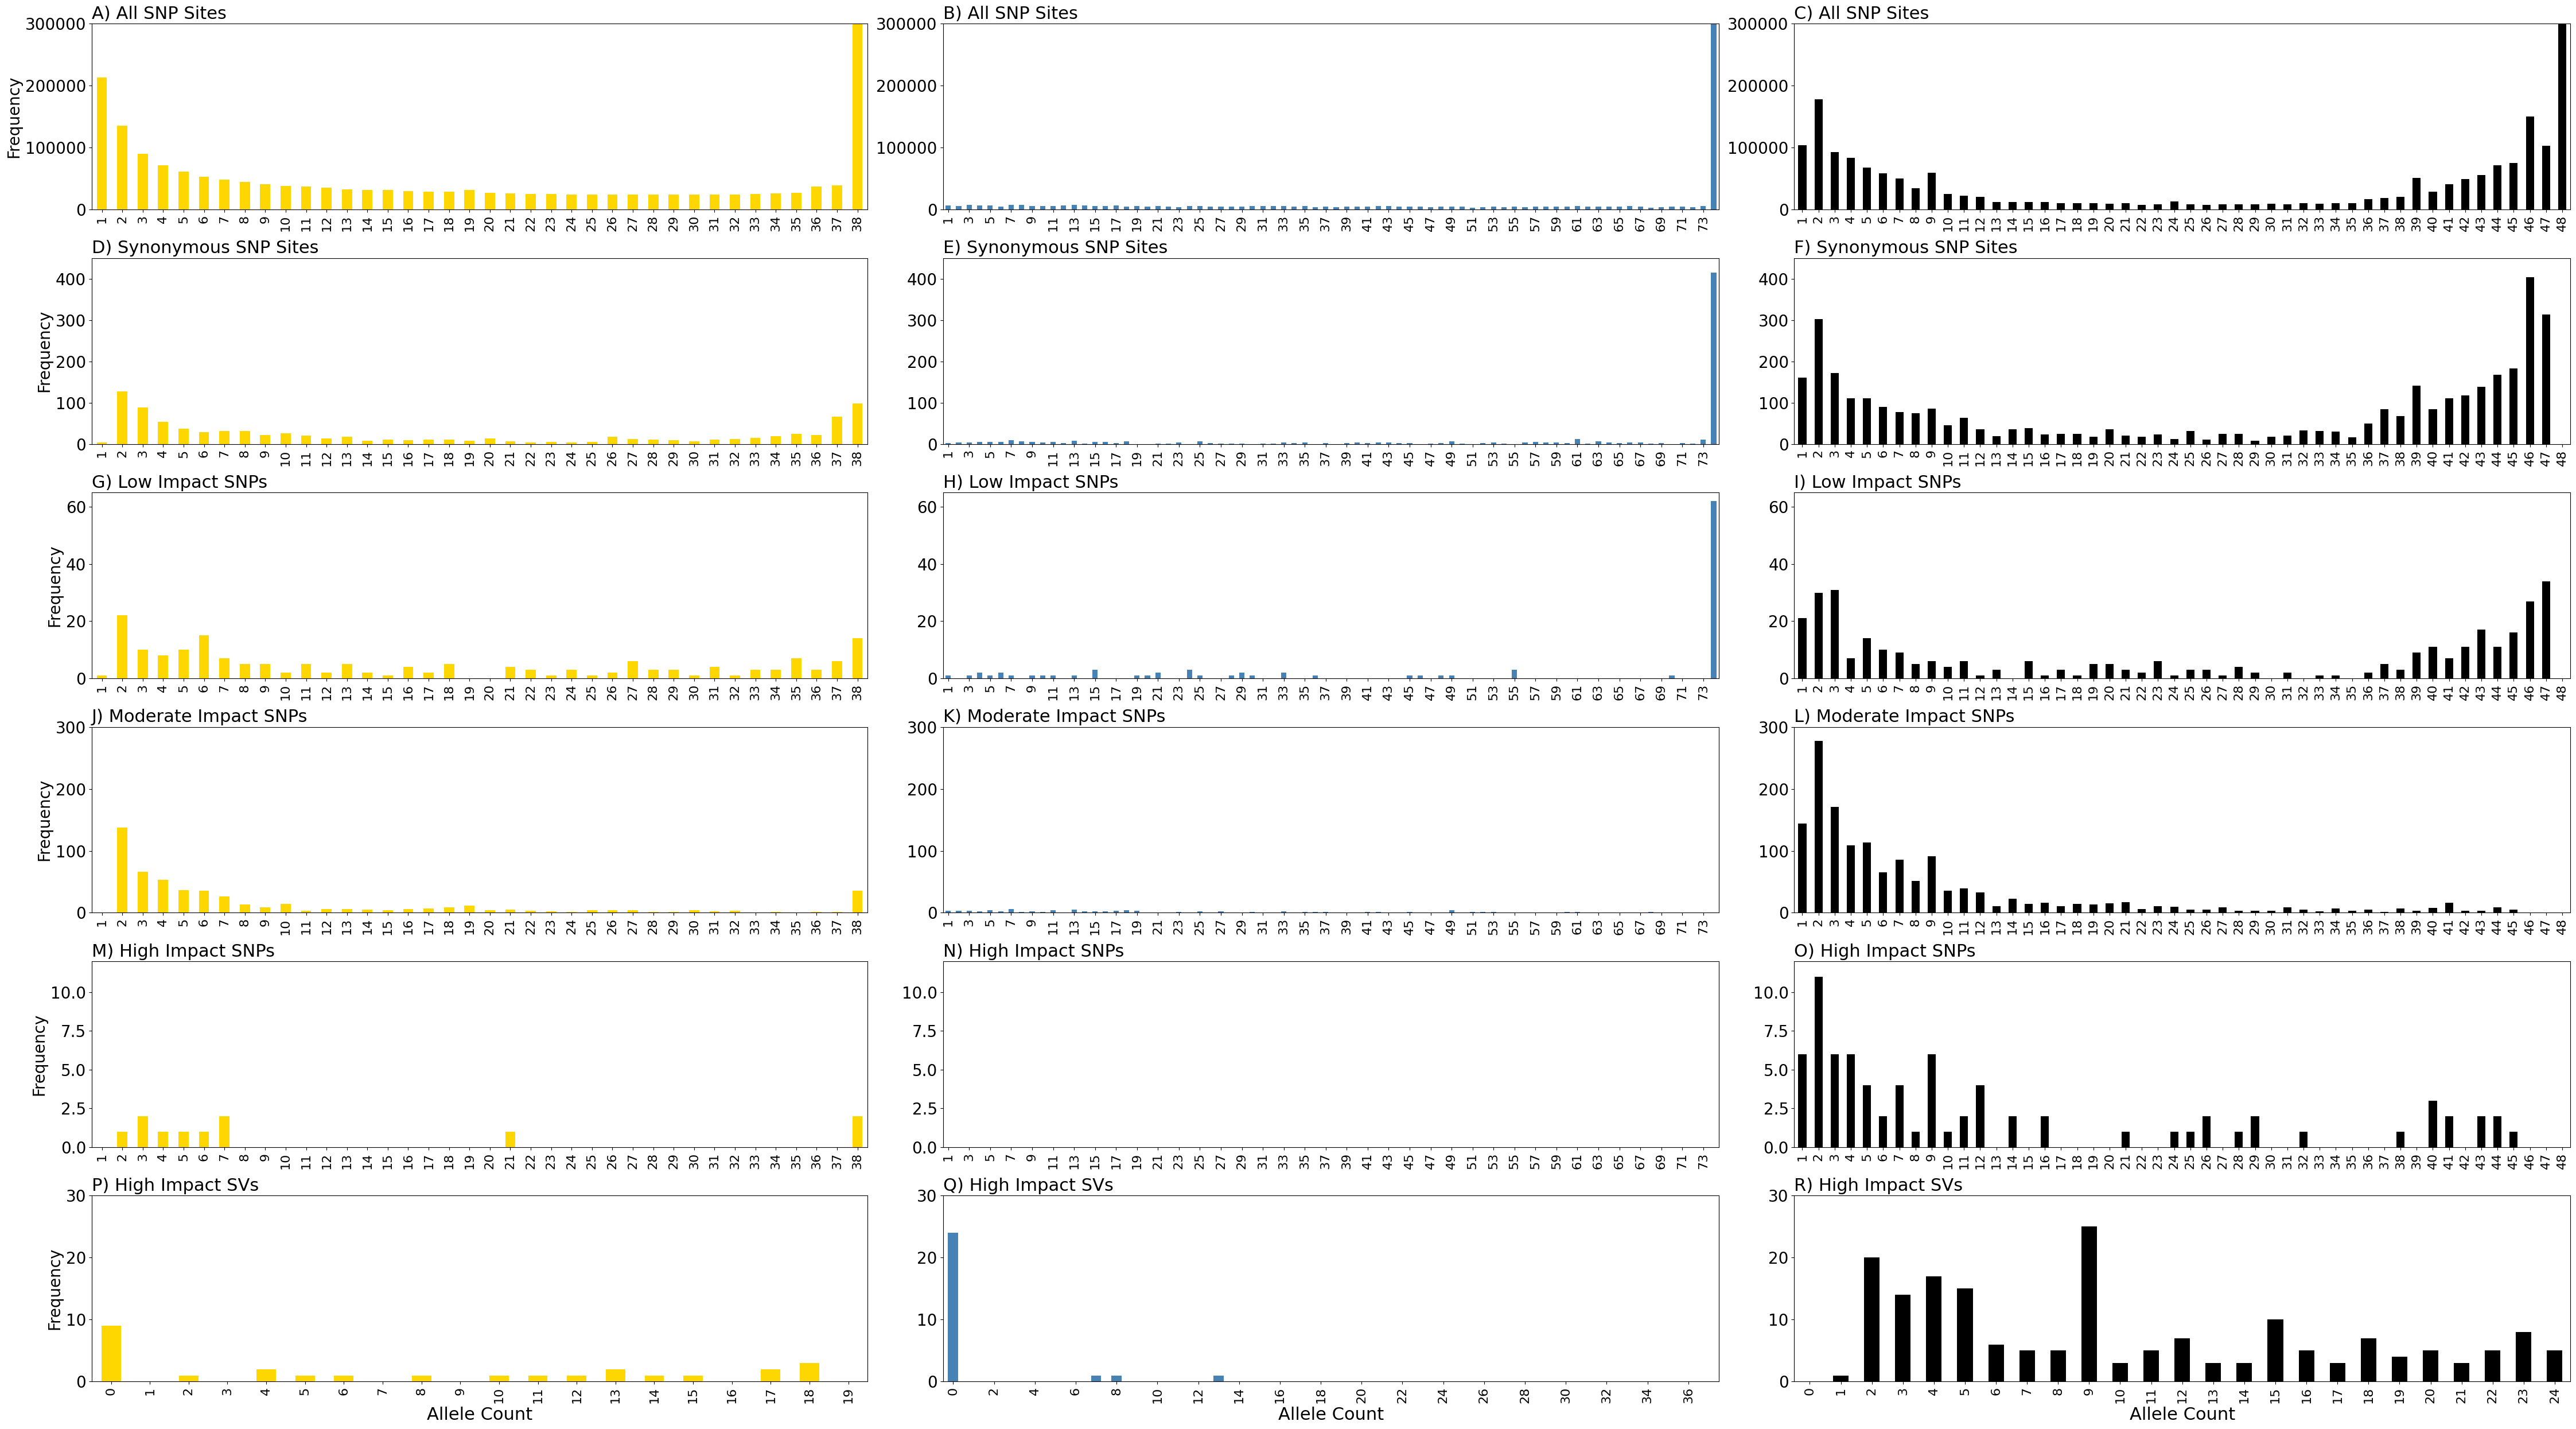

In [24]:
x_ausfs = ausfs['Allele Count']
x_tisfs = tisfs['Allele Count']
x_kisfs = kisfs['Allele Count']

# Create subplots FIRST
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(45, 25))

# Use ax[0,0].bar() instead of plt.bar()
ausfs.plot(kind="bar", stacked=True, ax=ax[0,0], legend=False, color='gold')
tisfs.plot(kind="bar", stacked=True, ax=ax[0,1], legend=False, color='steelblue')
kisfs.plot(kind="bar", stacked=True, ax=ax[0,2], legend=False, color='black')

# Stacked bar charts — row indices now consistent across all 3 columns
au_pivot.plot(kind="bar", stacked=True, ax=ax[1,0], color="gold", legend=False)
au_Lowpivot.plot(kind="bar", stacked=True, ax=ax[2,0], color="gold", legend=False)
au_Modpivot.plot(kind="bar", stacked=True, ax=ax[3,0], color="gold", legend=False)
au_Highpivot.plot(kind="bar", stacked=True, ax=ax[4,0], color="gold", legend=False)
au_svpivot.plot(kind="bar", stacked=True, ax=ax[5,0], color='gold', legend=False)

nz_pivot.plot(kind="bar", stacked=True, ax=ax[1,1], color="steelblue", legend=False)
nz_Lowpivot.plot(kind="bar", stacked=True, ax=ax[2,1], color="steelblue", legend=False)
nz_Modpivot.plot(kind="bar", stacked=True, ax=ax[3,1], color="steelblue", legend=False)
nz_Highpivot.plot(kind="bar", stacked=True, ax=ax[4,1], color="steelblue", legend=False)
nz_svpivot.plot(kind="bar", stacked=True, ax=ax[5,1], color="steelblue", legend=False)

ki_pivot.plot(kind="bar", stacked=True, ax=ax[1,2], color="black", legend=False)
ki_Lowpivot.plot(kind="bar", stacked=True, ax=ax[2,2], color="black", legend=False)
ki_Modpivot.plot(kind="bar", stacked=True, ax=ax[3,2], color="black", legend=False)
ki_Highpivot.plot(kind="bar", stacked=True, ax=ax[4,2], color="black", legend=False)
ki_svpivot.plot(kind="bar", stacked=True, ax=ax[5,2], color="black", legend=False)

for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    a.tick_params(axis='x', labelsize=16)
    a.tick_params(axis='y', labelsize=20)

# Row 0 — overall counts
ax[0,0].set_title('A) All SNP Sites', fontsize=22, loc='left')
ax[0,0].set_ylabel("Frequency", fontsize=20)
ax[0,1].set_title('B) All SNP Sites', fontsize=22, loc='left')
ax[0,2].set_title('C) All SNP Sites', fontsize=22, loc='left')
ax[0,0].set_ylim(0, 300000)
ax[0,1].set_ylim(0, 300000)
ax[0,2].set_ylim(0, 300000)

# Row 1
ax[1,0].set_title('D) Synonymous SNP Sites', fontsize=22, loc='left')
ax[1,0].set_ylabel("Frequency", fontsize=20)
ax[1,1].set_title('E) Synonymous SNP Sites', fontsize=22, loc='left')
ax[1,2].set_title('F) Synonymous SNP Sites', fontsize=22, loc='left')
ax[1,0].set_ylim(0, 450)
ax[1,1].set_ylim(0, 450)
ax[1,2].set_ylim(0, 450)

# Row 2
ax[2,0].set_title('G) Low Impact SNPs', fontsize=22, loc='left')
ax[2,0].set_ylabel("Frequency", fontsize=20)
ax[2,1].set_title('H) Low Impact SNPs', fontsize=22, loc='left')
ax[2,2].set_title('I) Low Impact SNPs', fontsize=22, loc='left')
ax[2,0].set_ylim(0, 65)
ax[2,1].set_ylim(0, 65)
ax[2,2].set_ylim(0, 65)

# Row 3
ax[3,0].set_title('J) Moderate Impact SNPs', fontsize=22, loc='left')
ax[3,0].set_ylabel("Frequency", fontsize=20)
ax[3,1].set_title('K) Moderate Impact SNPs', fontsize=22, loc='left')
ax[3,2].set_title('L) Moderate Impact SNPs', fontsize=22, loc='left')
ax[3,0].set_ylim(0, 300)
ax[3,1].set_ylim(0, 300)
ax[3,2].set_ylim(0, 300)

# Row 4
ax[4,0].set_title('M) High Impact SNPs', fontsize=22, loc='left')
ax[4,0].set_ylabel("Frequency", fontsize=20)
ax[4,1].set_title('N) High Impact SNPs', fontsize=22, loc='left')
ax[4,2].set_title('O) High Impact SNPs', fontsize=22, loc='left')
ax[4,0].set_ylim(0, 12)
ax[4,1].set_ylim(0, 12)
ax[4,2].set_ylim(0, 12)

# Row 5 — sv pivots (add titles/ylims to match your data)
ax[5,0].set_title('P) High Impact SVs', fontsize=22, loc='left')
ax[5,0].set_ylabel("Frequency", fontsize=20)
ax[5,1].set_title('Q) High Impact SVs', fontsize=22, loc='left')
ax[5,2].set_title('R) High Impact SVs', fontsize=22, loc='left')
ax[5,0].set_ylim(0, 30)
ax[5,1].set_ylim(0, 30)
ax[5,2].set_ylim(0, 30)

# X labels on the bottom row only
ax[5,0].set_xlabel("Allele Count", fontsize=22)
ax[5,1].set_xlabel("Allele Count", fontsize=22)
ax[5,2].set_xlabel("Allele Count", fontsize=22)

for a in [ax[0,1], ax[1,1], ax[2,1], ax[3,1], ax[4,1], ax[5,1]]:  # whichever axes you want
    ticks = a.get_xticks()
    a.set_xticks(ticks[::2])

plt.tight_layout()
plt.savefig('Figures/Figure6_SFS.svg', bbox_inches='tight')

Accross the board, we see that tara iti consistently have fewer derived alleles overall than either Australia fairy tern or kakī. In general, derived alleles are absent from the tara iti population in the Moderate or High impact categories, or either absent or fixed in the low category. This isn't surprising as the Low impact category is intended to capture nearly neutral alleles and as a result they are likely under less selection and more prone to genetic drift.  

 

Immediately it is clear that Australian fairy tern have a high number of fixed High impact SVs. While this is likely true relative to the tara iti reference genome, it is challenging to know the context of these BUSCO regions in the AFT population of WA.  

In [21]:
print('The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in AFT: ', synonymous_count[synonymous_count['Population']=='AU']['Allele Frequency'].mean(), ',', pop_snps[(pop_snps['Population']=='AU') & (pop_snps['Consequence']!='MODIFIER') & (pop_snps['Consequence']!='LOW')]['Allele Frequency'].mean(), ' & ', pop_svs[(pop_svs['Population']=='AU') & (pop_svs['Consequence']!='MODIFIER')]['Allele Frequency'].mean())
print('The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in TI:  ', synonymous_count[synonymous_count['Population']=='NZ']['Allele Frequency'].mean(), ',', pop_snps[(pop_snps['Population']=='NZ') & (pop_snps['Consequence']!='MODIFIER') & (pop_snps['Consequence']!='LOW')]['Allele Frequency'].mean(), ' & ', pop_svs[(pop_svs['Population']=='NZ') & (pop_svs['Consequence']!='MODIFIER')]['Allele Frequency'].mean())
print('The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in KI:  ', synonymous_count[synonymous_count['Population']=='KI']['Allele Frequency'].mean(), ',', pop_snps[(pop_snps['Population']=='KI') & (pop_snps['Consequence']!='MODIFIER') & (pop_snps['Consequence']!='LOW')]['Allele Frequency'].mean(), ' & ', pop_svs[(pop_svs['Population']=='KI') & (pop_svs['Consequence']!='MODIFIER')]['Allele Frequency'].mean())

The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in AFT:  0.3236842105263158 , 0.22172359707215059  &  0.5939849624060151
The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in TI:   0.40808665808665806 , 0.03389565061750493  &  0.013513513513513514
The mean allele frequency of synonymous SNPs and putatively harmful SNPs and SVs in KI:   0.5573643150929901 , 0.18087906828334396  &  0.3066123188405797


We then compared the number of derived sites present in each of the populations by their putative impact as ascertained by VEP.  

Filter the data to exclude KI from Rxy esimtates and those sites with ambiguous impacts (i.e., MODIFIER).  

We then attempted to include SVs in our estimates of R<sub>XY</sub> by using our synonymous SNPs. For this we extracted synonymous SNPs and merged them with the SV data.  

## Plots of putatively harmful allele counts and relative diversity
Now we examine the total number of putatively harmful derived alleles (`Allele Count`), then the number of putatively harmful derived alleles in a 'masked' state (`Het Allele Count`), and finally the number of puatively harmful alleles likely contributing to realised load (`Hom Allele Count`).

C:\Users\jwold\AppData\Local\Temp\ipykernel_14792\2195722637.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  syn['Consequence'] = 'Synonymous'
C:\Users\jwold\AppData\Local\Temp\ipykernel_14792\2195722637.py:21: UserWarning: 
The palette list has fewer values (3) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(tot_snp, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[0])
C:\Users\jwold\AppData\Local\Temp\ipykernel_14792\2195722637.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Synonymous', 'Synonymous', 'Synonym

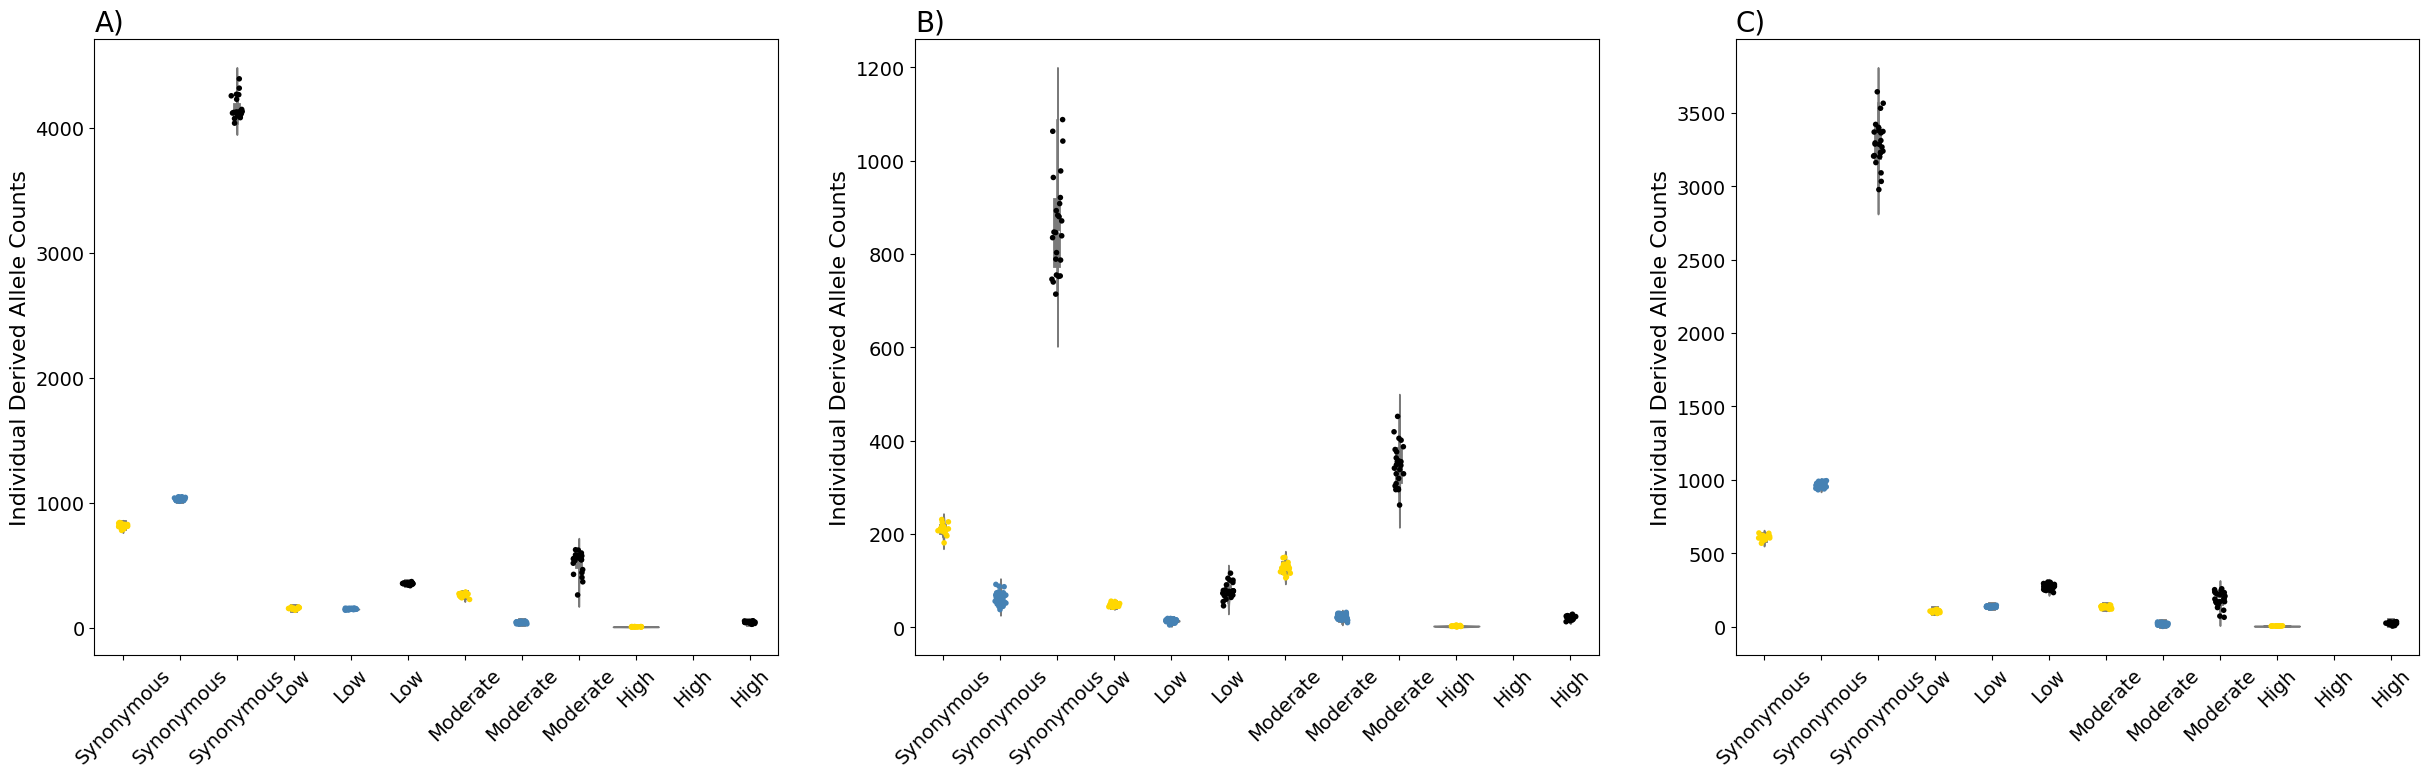

In [88]:
snp_load = snp_vep[(snp_vep['Consequence']!='MODIFIER') & (snp_vep['Mutation Class']!='synonymous_variant') & (snp_vep['Allele Count']>0)]
syn = snp_vep[(snp_vep['Consequence']!='MODIFIER') & (snp_vep['Mutation Class']=='synonymous_variant') & (snp_vep['Allele Count']>0)]
syn['Consequence'] = 'Synonymous'

snp_load = pd.concat([snp_load, syn])
snp_load['Pop-Consequence'] = snp_load['Population'] +'-' + snp_load['Consequence']

tot_snp = snp_load.groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
het_snp = snp_load[snp_load['Genotype Category']=='Het'].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
alt_snp = snp_load[snp_load['Genotype Category']=='Hom Alt'].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()

palette = ['gold', 'steelblue', 'black']
order = ['AU-Synonymous', 'NZ-Synonymous', 'KI-Synonymous', 
         'AU-LOW', 'NZ-LOW', 'KI-LOW', 
         'AU-MODERATE', 'NZ-MODERATE', 'KI-MODERATE', 
         'AU-HIGH', 'NZ-HIGH', 'KI-HIGH']

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharex=False, sharey=False)

sns.violinplot(tot_snp, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[0])
sns.stripplot(tot_snp, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[0])
axes[0].set_title('A)', loc='left', fontsize=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Individual Derived Allele Counts', fontsize=16)
axes[0].set_xticklabels(['Synonymous', 'Synonymous', 'Synonymous', 'Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[0].tick_params(axis='y', which='major', labelsize=14)
#axes[0].set_ylim(0,800)

sns.violinplot(het_snp, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[1])
sns.stripplot(het_snp, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[1])
axes[1].set_title('B)', loc='left', fontsize=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Individual Derived Allele Counts', fontsize=16)
axes[1].set_xticklabels(['Synonymous', 'Synonymous', 'Synonymous', 'Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[1].tick_params(axis='y', which='major', labelsize=14)
#axes[1].set_ylim(0,500)

sns.violinplot(alt_snp, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[2])
sns.stripplot(alt_snp, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[2])
axes[2].set_title('C)', loc='left', fontsize=20)
axes[2].set_xlabel('')
axes[2].set_ylabel('Individual Derived Allele Counts', fontsize=16)
axes[2].set_xticklabels(['Synonymous', 'Synonymous', 'Synonymous', 'Low', 'Low', 'Low', 'Moderate', 'Moderate', 'Moderate', 'High', 'High', 'High'], fontsize = 14, rotation=45)
axes[2].tick_params(axis='y', which='major', labelsize=14)
#axes[2].set_ylim(0,500)

#plt.savefig('Figures/Figure6_load_SNP_summary.png', dpi=300, bbox_inches='tight')

In [54]:
snp_load.head()

,Chromosome,Position,Sample,Mutation Class,Consequence,Population,Allele Count,Genotype Category,Pop-Consequence
10015,CM020437.1_RagTag,3195932,AU04,splice_region_variant&splice_polypyrimidine_tr...,LOW,AU,1,Het,AU-LOW
10027,CM020437.1_RagTag,3195932,AU27,splice_region_variant&splice_polypyrimidine_tr...,LOW,AU,1,Het,AU-LOW
10135,CM020437.1_RagTag,3198660,AU17,missense_variant,MODERATE,AU,1,Het,AU-MODERATE
10141,CM020437.1_RagTag,3198660,AU27,missense_variant,MODERATE,AU,1,Het,AU-MODERATE
11094,CM020437.1_RagTag,3307436,AU30,missense_variant,MODERATE,AU,1,Het,AU-MODERATE


### SV load plots

C:\Users\jwold\AppData\Local\Temp\ipykernel_24916\3253361347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  indiv_SVdel['Pop-Consequence'] = indiv_SVdel['Population'] + '-' + indiv_SVdel['Consequence']
C:\Users\jwold\AppData\Local\Temp\ipykernel_24916\3253361347.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['High', 'High', 'High'], fontsize = 14, rotation=45)
C:\Users\jwold\AppData\Local\Temp\ipykernel_24916\3253361347.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['High', 'High', 'High'], fontsize = 14, rotation=4

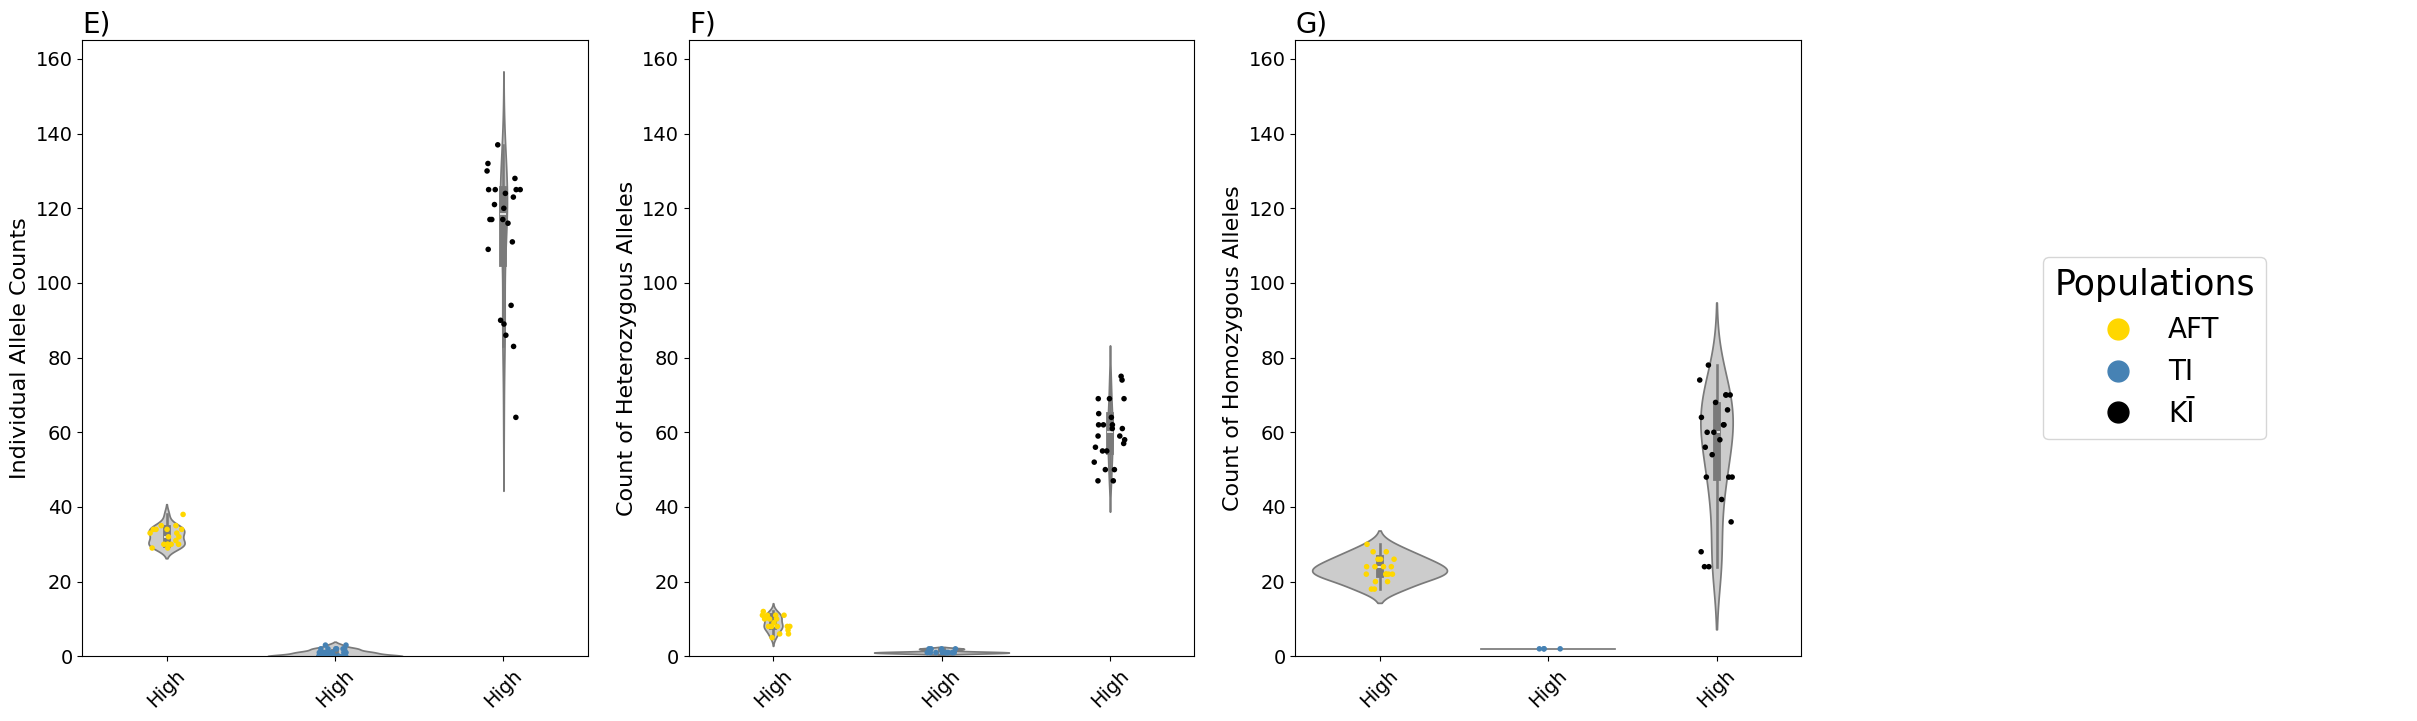

In [22]:
import matplotlib.lines as mlines

indiv_SVdel = sv_vep[sv_vep['Consequence']!='MODIFIER']

indiv_SVdel['Pop-Consequence'] = indiv_SVdel['Population'] + '-' + indiv_SVdel['Consequence']

tot_sv = indiv_SVdel.groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
het_sv = indiv_SVdel[indiv_SVdel['Genotype Category']=='Het'].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()
alt_sv = indiv_SVdel[indiv_SVdel['Genotype Category']=='Hom Alt'].groupby(['Sample', 'Pop-Consequence'])['Allele Count'].sum().reset_index()

palette = ['gold', 'steelblue', 'black']
order = ['AU-HIGH', 'NZ-HIGH', 'KI-HIGH']

fig, axes = plt.subplots(1, 4, figsize=(30, 8), sharex=False, sharey=False)

sns.violinplot(tot_sv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[0])
sns.stripplot(tot_sv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[0])
axes[0].set_title('E)', loc='left', fontsize=20)
axes[0].set_xlabel('')
axes[0].set_ylabel('Individual Allele Counts', fontsize=16)
axes[0].set_xticklabels(['High', 'High', 'High'], fontsize = 14, rotation=45)
axes[0].tick_params(axis='y', which='major', labelsize=14)
axes[0].set_ylim(0, 165)

sns.violinplot(het_sv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[1])
sns.stripplot(het_sv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[1])
axes[1].set_title('F)', loc='left', fontsize=20)
axes[1].set_xlabel('')
axes[1].set_ylabel('Count of Heterozygous Alleles', fontsize=16)
axes[1].set_xticklabels(['High', 'High', 'High'], fontsize = 14, rotation=45)
axes[1].tick_params(axis='y', which='major', labelsize=14)
axes[1].set_ylim(0, 165)

sns.violinplot(alt_sv, x='Pop-Consequence', y='Allele Count', order=order, color='0.8', ax=axes[2])
sns.stripplot(alt_sv, x='Pop-Consequence', y='Allele Count', hue='Pop-Consequence', hue_order=order, palette=palette, jitter=True, size=4, ax=axes[2])
axes[2].set_title('G)', loc='left', fontsize=20)
axes[2].set_xlabel('')
axes[2].set_ylabel('Count of Homozygous Alleles', fontsize=16)
axes[2].set_xticklabels(['High', 'High', 'High'], fontsize = 14, rotation=45)
axes[2].tick_params(axis='y', which='major', labelsize=14)
axes[2].set_ylim(0, 165)

axes[3].axis('off')

# Define custom legend elements
legend_labels = ['AFT', 'TI', 'KĪ']
legend_colors = ['gold', 'steelblue', 'black']  # Adjust colors as needed
handles = [mlines.Line2D([], [], color=color, marker='o', markersize=15, linestyle='None', label=label) for color, label in zip(legend_colors, legend_labels)]

# Add the custom legend to the fourth subplot
axes[3].legend(handles=handles, loc='center', fontsize=20, title='Populations', title_fontsize=25)

plt.savefig('Figures/Figure6_load_SV_summary.png', dpi=300, bbox_inches='tight')